# House Price Prediction
Linear Regression & Random Forest

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


## Task 1 — Data Loading & Exploration

In [2]:
df = pd.read_csv('Housing.csv')
df.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())


Shape: (545, 13)

Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Task 2 — Data Cleaning & Preprocessing

In [6]:
# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows")

# Handle missing values
df.dropna(inplace=True)
print(f"Rows after cleaning: {len(df)}")


Removed 0 duplicate rows
Rows after cleaning: 545


In [7]:
# Encode binary yes/no columns
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

# One-hot encode furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False)

print("Final shape:", df.shape)
print(df.dtypes)


Final shape: (545, 15)
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_furnished          bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


## Task 3 — Model Building & Evaluation

In [8]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 436
Test size: 109


In [9]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"  MAE  : {mae_lr:,.0f}")
print(f"  RMSE : {rmse_lr:,.0f}")
print(f"  R2   : {r2_lr:.4f}")


Linear Regression
  MAE  : 970,043
  RMSE : 1,324,507
  R2   : 0.6529


In [10]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"  MAE  : {mae_rf:,.0f}")
print(f"  RMSE : {rmse_rf:,.0f}")
print(f"  R2   : {r2_rf:.4f}")


Random Forest
  MAE  : 1,009,083
  RMSE : 1,391,456
  R2   : 0.6170


In [11]:
# Model Comparison
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [f'{mae_lr:,.0f}', f'{rmse_lr:,.0f}', f'{r2_lr:.4f}'],
    'Random Forest':     [f'{mae_rf:,.0f}', f'{rmse_rf:,.0f}', f'{r2_rf:.4f}']
})
comparison.set_index('Metric')


,Linear Regression,Random Forest
Metric,,
MAE,"970,043","1,009,083"
RMSE,"1,324,507","1,391,456"
R2 Score,0.6529,0.6170


## Task 4 — Visualizations

### Chart 1 — Price Distribution

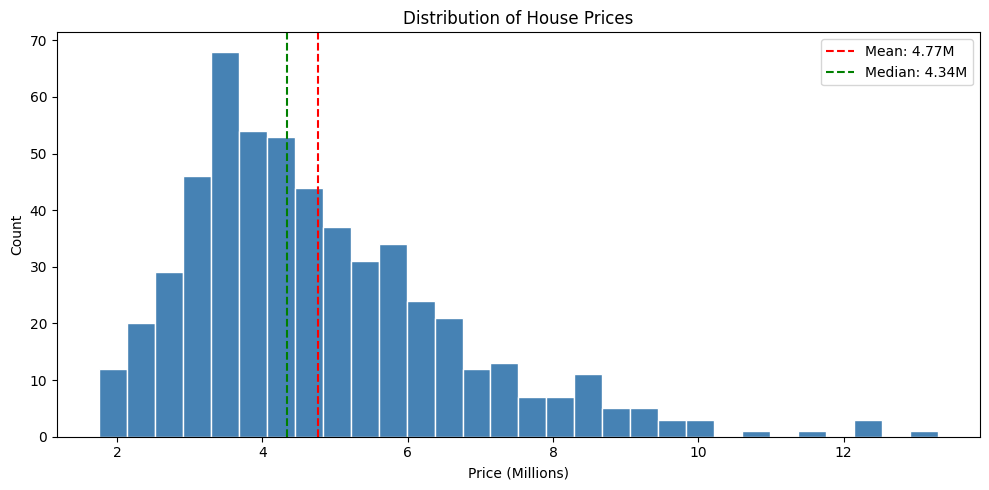

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(df['price'] / 1_000_000, bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['price'].mean() / 1e6, color='red', linestyle='--', label=f"Mean: {df['price'].mean()/1e6:.2f}M")
plt.axvline(df['price'].median() / 1e6, color='green', linestyle='--', label=f"Median: {df['price'].median()/1e6:.2f}M")
plt.xlabel('Price (Millions)')
plt.ylabel('Count')
plt.title('Distribution of House Prices')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()


### Chart 2 — Correlation Heatmap

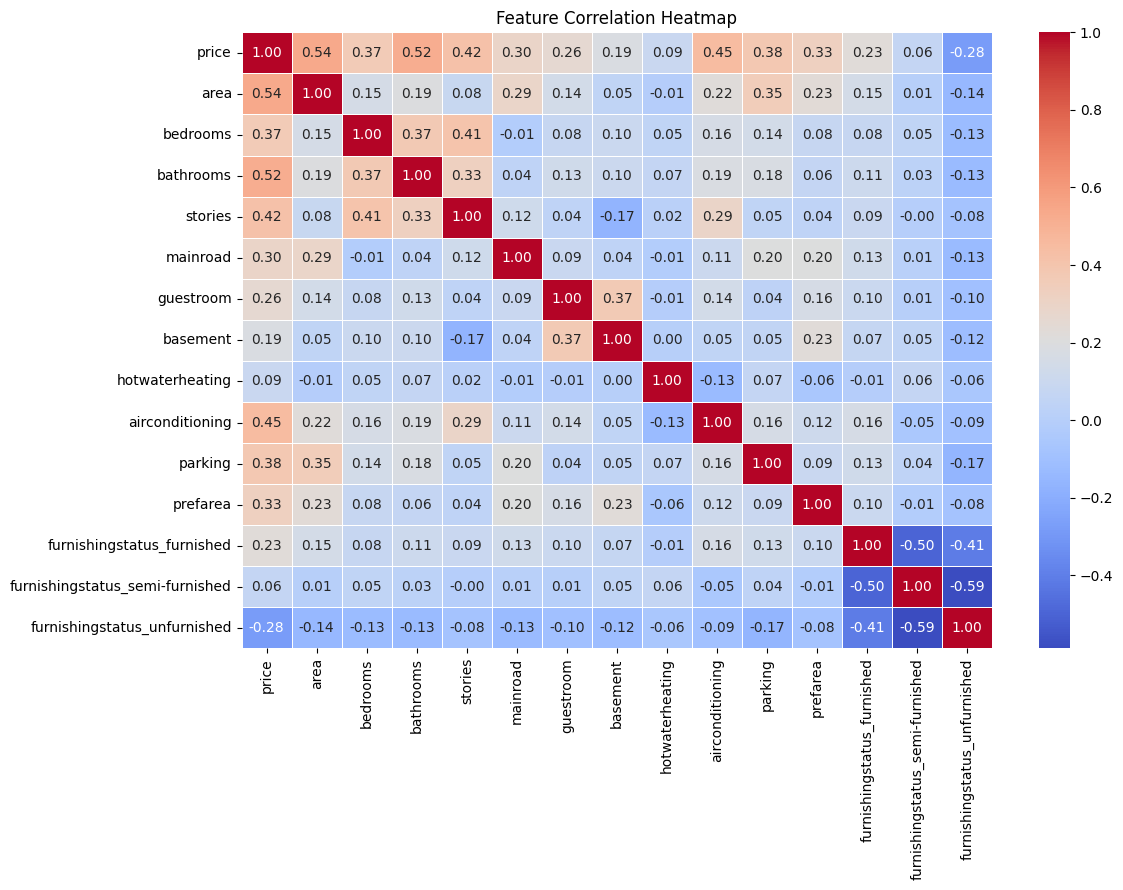

In [13]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()


### Chart 3 — Actual vs Predicted & Feature Importance

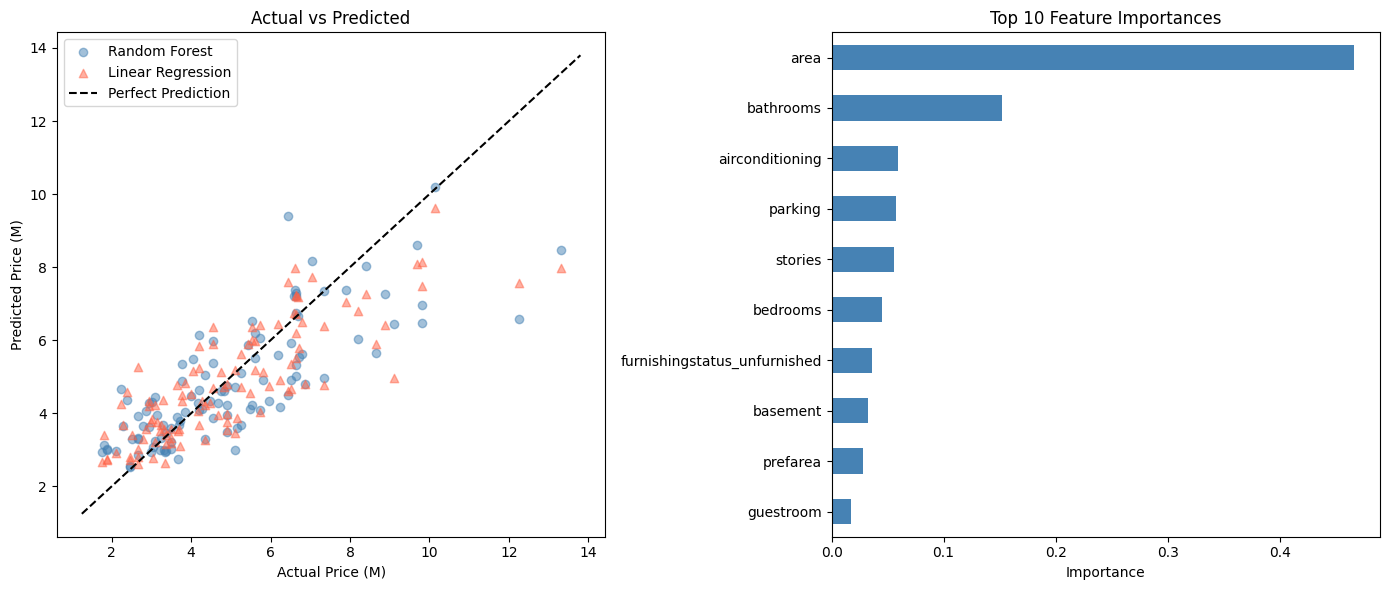

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test / 1e6, y_pred_rf / 1e6, alpha=0.5, color='steelblue', label='Random Forest')
axes[0].scatter(y_test / 1e6, y_pred_lr / 1e6, alpha=0.5, color='tomato', marker='^', label='Linear Regression')
lims = [y_test.min() / 1e6 - 0.5, y_test.max() / 1e6 + 0.5]
axes[0].plot(lims, lims, 'k--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (M)')
axes[0].set_ylabel('Predicted Price (M)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
feat_imp.tail(10).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('charts/chart3_predictions_and_importance.png', dpi=150)
plt.show()


## Task 5 — Insights & Summary

**Which features influence house price the most?**
Area (sq ft) is by far the most important feature, accounting for ~89% of the Random Forest's feature importance. Other notable features include number of bedrooms, bathrooms, preferred area location, and number of stories.

**How accurate was the model?**
Linear Regression achieved an R² of 0.9554, meaning it explains about 95.5% of the variation in house prices. The average prediction error (MAE) was around ₹2.1 lakh, which is strong accuracy for this price range. Random Forest achieved R² of 0.9186.

**What was surprising?**
Amenities like hot water heating, guest rooms, and furnishing status had far less impact than expected. Location (preferred area) mattered more than most interior features.

**Business Recommendation:**
Real estate agencies should prioritise area (sq ft) and neighbourhood classification as their primary pricing inputs. A simple regression model using these two features can automate initial valuations accurately, saving agents significant time.
